In [1]:
# out 2,  loss = 1-cos()
# vqc_mlp_pennylane_pipeline.py
import os
import time
import numpy as np
from numpy.polynomial.hermite import hermgauss
import pennylane as qml
import pennylane.numpy as pnp
import matplotlib.pyplot as plt
from itertools import combinations
import copy

# -----------------------
# === User parameters ===
# -----------------------
n_qubits = 8            # number of qubits (be careful: statevector dim = 2^n_qubits)
n_enc, n_dec = 1, 1     # encoding / decoding layers
phi_train_samples = 100
n_phi = 50              # points for QFI/CFI plotting
dphi = 1e-5             # small for numeric stability if needed (we use analytic jacobians)
maxiter = 3000           # training iterations (set small for debugging)
seed = 42
np.random.seed(seed)
shots=None

# output path
path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/elu"
os.makedirs(path, exist_ok=True)


# =========================================
# 2. 均匀分布训练集 + 测试集
# =========================================
phi_train = np.linspace(-np.pi, np.pi, phi_train_samples)
weights = np.ones_like(phi_train) / len(phi_train)
phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, np.pi + np.pi/phi_train_samples, n_phi)

# -----------------------
# === Precompute index->m mapping ===
# -----------------------
dim = 2 ** n_qubits
index_to_m = np.zeros(dim, dtype=int)
for idx in range(dim):
    bitstr = format(idx, f"0{n_qubits}b")
    m = bitstr.count('0') - bitstr.count('1')
    index_to_m[idx] = m
unique_m = np.unique(index_to_m)           # array of length 2*n_qubits+1

# reorder unique_m ascending (already is)
unique_m = np.sort(unique_m)
m_masks = [np.where(index_to_m == m)[0] for m in unique_m]

# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev = qml.device("default.qubit", wires=n_qubits, shots=shots)

# convenience rzz implementation to match earlier qiskit-like pattern
def rzz_qiskit(chi, i, j):
    qml.CNOT(wires=[i, j])
    qml.RZ(chi, wires=j)
    qml.CNOT(wires=[i, j])

# We'll create QNodes that take (phi, flat_params) where flat_params encodes
# quantum parameters only (theta_flat and curly_flat). MLP params live in same
# big vector x but will be ignored by circuit QNodes (we'll unpack).
@qml.qnode(dev, interface="autograd")
def circuit_state(phi, q_params):
    """Return pure state vector for given phi and quantum parameters q_params."""
    # q_params is a flat array containing theta_flat (3*n_enc) then curly_flat (3*n_dec)
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding layers
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        # twisting_z
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        # twisting_x
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        # collective rx
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase encoding
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding layers
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.state()

@qml.qnode(dev, interface="autograd")
def circuit_probs(phi, q_params):
    """Return computational-basis probabilities for given phi and quantum parameters q_params."""
    # build same circuit but return probs
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=list(range(n_qubits)))


def sigmoid(x):
    return 1 / (1 + pnp.exp(-x))

def softplus(x):
    return pnp.log1p(pnp.exp(x))

def elu(x, alpha=1.0):
    return pnp.where(x > 0, x, alpha * (pnp.exp(x) - 1))
    
def softsign(x):
    return x/(1+pnp.abs(x))
    

class MLP:
    def __init__(self, dim_in, dim_hidden=128, seed=0):
        r = np.random.RandomState(seed)
        h = dim_hidden
        self.W1, self.b1 = pnp.array(r.randn(h, dim_in)*0.1, requires_grad=True), pnp.zeros(h, requires_grad=True)
        self.W2, self.b2 = pnp.array(r.randn(h//2, h)*0.1, requires_grad=True), pnp.zeros(h//2, requires_grad=True)
        self.W3, self.b3 = pnp.array(r.randn(2, h//2)*0.1, requires_grad=True), pnp.zeros(2, requires_grad=True)

    def __call__(self, p_m):
        h1 = elu(self.W1 @ p_m + self.b1)
        h2 = elu(self.W2 @ h1 + self.b2)
        out = self.W3 @ h2 + self.b3
        return out / (pnp.linalg.norm(out) + 1e-6)

    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

# -----------------------
# === Pack/unpack parameters (quantum + mlp) ===
# -----------------------
def pack_params(q_theta_flat, q_curly_flat, mlp_params):
    arrs = [np.ravel(q_theta_flat), np.ravel(q_curly_flat)]
    for p in mlp_params:
        arrs.append(np.ravel(p))
    return pnp.array(np.concatenate(arrs), requires_grad=True)

def unpack_params(x):
    """
    From global flat parameter x, extract:
      - q_theta_flat: length 3*n_enc
      - q_curly_flat: length 3*n_dec
      - mlp params: shapes matching net.parameters()
    """
    t_len = 3 * n_enc
    c_len = 3 * n_dec

    offset = 0
    theta_flat = x[offset: offset + t_len] if t_len > 0 else pnp.array([])
    offset += t_len
    curly_flat = x[offset: offset + c_len] if c_len > 0 else pnp.array([])
    offset += c_len

    shapes = [p.shape for p in net.parameters()]
    sizes = [int(np.prod(s)) for s in shapes]

    mlp_params = []
    for s in sizes:
        arr = x[offset: offset + s]
        mlp_params.append(arr)
        offset += s

    # reshape mlp params back
    reshaped = []
    for arr, shape in zip(mlp_params, shapes):
        reshaped.append(arr.reshape(shape))
    return theta_flat, curly_flat, reshaped

# -----------------------
# === Helper: get p_m aggregated over m-values from probs vector ===
# -----------------------
def probs_to_p_m(probs):
    # probs: vector length 2^n_qubits
    # returns vector of length len(unique_m) where each entry sums probabilities of basis states with same m
    return pnp.array([pnp.sum(probs[idx]) for idx in m_masks])

def compute_probs_batch(phi_list, q_params):
    probs_list = []
    for phi in phi_list:
        probs_list.append(circuit_probs(phi, q_params))
    return probs_list
    
# -----------------------
# === Loss: Hermite-Gauss weighted BMSE using MLP predictions ===
# -----------------------
def compute_bmse_from_probs_vectorized(x, phi_list_local, weights_local):
    # Unpack parameters and update the net's parameters for use in forward
    theta_flat, curly_flat, mlp_params = unpack_params(x)
    # q_params for QNodes should be concatenation of theta and curly (quantum params)
    q_params = pnp.concatenate([theta_flat, curly_flat]) if (len(theta_flat) + len(curly_flat)) > 0 else pnp.array([])
    # set net parameters (they are pnp arrays)
    net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = mlp_params
    
    bmse_list = []
    # loop over quadrature nodes
    for phi, w in zip(phi_list_local, weights_local):
        # compute computational basis probabilities with quantum parameters only
        probs = circuit_probs(phi, q_params)   # pnp array length 2^n_qubits
        p_m = probs_to_p_m(probs)              # aggregated over m
        v = net(p_m)                      # shape (2,)
        phi_pred = pnp.arctan2(v[0], v[1])
        bmse = 2*(1 - pnp.cos(phi - phi_pred))
        bmse_list.append(bmse * w)
    return pnp.sum(pnp.stack(bmse_list))

def objective(x):
    return compute_bmse_from_probs_vectorized(x, phi_train, weights)

# ---------------------------
# 3. QFI 计算函数
# ---------------------------
def compute_QFI(phi, x, dphi=dphi):
    """中心差分计算纯态下的 CFI 和 QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_q)

def adjust_phase_wrap(phi_true, phi_pred):
    """
    修正预测角度，使其在与真实角度相同的周期内（处理±π边界问题）。

    参数:
        phi_true: np.ndarray，真实相位（形状 [N]）
        phi_pred: np.ndarray，预测相位（形状 [N]）

    返回:
        phi_pred_adj: np.ndarray，修正后的预测相位
    """
    phi_pred_adj = phi_pred.copy()
    mask = np.abs(phi_true - phi_pred) > np.pi
    phi_pred_adj[mask] -= np.sign(phi_pred[mask]) * 2 * np.pi
    return phi_pred_adj

def evaluate_model(x):
    """计算当前模型的 test MSE 和 QFI"""
    
    theta_flat, curly_flat, mlp_params = unpack_params(x)
    net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = mlp_params
    q_params = pnp.concatenate([theta_flat, curly_flat])

    # -------- MSE --------
    phi_preds = []
    probs_list = compute_probs_batch(phi_trues, q_params)

    for probs in probs_list:
        p_m = probs_to_p_m(probs)
        v = net(p_m)
        phi_pred = pnp.arctan2(v[0], v[1])
        phi_preds.append(float(phi_pred))

    phi_preds = np.array(phi_preds)
    phi_preds = adjust_phase_wrap(phi_trues, phi_preds)
    mse = np.mean((phi_preds - phi_trues) ** 2)

    # -------- QFI --------
    qfi = compute_QFI(0.0, q_params)

    return mse, qfi
    
# instantiate network
net = MLP(dim_in=len(unique_m), dim_hidden=128)

# -----------------------
# === Build initial flat parameter vector x ===
# -----------------------
theta_init = np.random.uniform(-0.1, 0.1, 3 * n_enc) if n_enc > 0 else np.array([])
curly_init = np.random.uniform(-0.1, 0.1, 3 * n_dec) if n_dec > 0 else np.array([])
mlp_initial = net.parameters()
x0 = pack_params(theta_init, curly_init, mlp_initial)
x = pnp.array(x0, requires_grad=True)

# -----------------------
# === Training ===
# -----------------------
opt = qml.AdamOptimizer(stepsize=0.02)
mse_history = []
test_mse_list = []
qfi_list = []
epoch_list = []

best_loss = np.inf
best_x = None
best_it = -1
patience = 100              # 连续50次不提升就停止
no_improve_count = 0
min_iters = 500
print("Starting training...")
t0 = time.time()

for it in range(0, maxiter + 1):
    x, loss_val = opt.step_and_cost(objective, x)
    loss_val_f = float(loss_val)
    mse_history.append(loss_val_f)

    # ---- save best ----
    if loss_val_f < best_loss:
        best_loss = loss_val_f
        best_x = pnp.array(x, requires_grad=True)  # deep copy
        best_it = it
        no_improve_count = 0   # 有提升，清零
    else:
        no_improve_count += 1  # 没提升，计数+1

    if it % 5 == 0 or it <= 5:
        print(f"Iter {it:4d} | loss={loss_val_f:.6e} | best={best_loss:.6e} | no_improve={no_improve_count}")

    # ---- 每10epoch测试一次 ----
    if it % 10 == 0:
        mse_test, qfi = evaluate_model(x)
        test_mse_list.append(mse_test)
        qfi_list.append(qfi)
        epoch_list.append(it)
        print(f"Eval epoch {it}:  MSE={mse_test:.3e}  QFI={qfi:.3f}")

    # ---- early stopping ----
    if it > min_iters and no_improve_count >= patience:
        print(f"\nEarly stopping at iter {it}, no improvement for {patience} iterations.")
        break

print(f"\nTraining finished in {time.time()-t0:.1f}s")
print(f"Best loss {best_loss:.6e} at iter {best_it}")


Starting training...
Iter    0 | loss=2.067064e+00 | best=2.067064e+00 | no_improve=0
Eval epoch 0:  MSE=2.708e+00  QFI=6.871
Iter    1 | loss=1.718283e+00 | best=1.718283e+00 | no_improve=0
Iter    2 | loss=1.378041e+00 | best=1.378041e+00 | no_improve=0
Iter    3 | loss=1.082441e+00 | best=1.082441e+00 | no_improve=0
Iter    4 | loss=9.208524e-01 | best=9.208524e-01 | no_improve=0
Iter    5 | loss=8.497202e-01 | best=8.497202e-01 | no_improve=0
Iter   10 | loss=7.436412e-01 | best=7.436412e-01 | no_improve=0
Eval epoch 10:  MSE=8.588e-01  QFI=7.800
Iter   15 | loss=7.595771e-01 | best=7.388228e-01 | no_improve=3
Iter   20 | loss=7.804821e-01 | best=7.388228e-01 | no_improve=8
Eval epoch 20:  MSE=9.671e-01  QFI=7.822
Iter   25 | loss=7.427418e-01 | best=7.388228e-01 | no_improve=13
Iter   30 | loss=6.865468e-01 | best=6.865468e-01 | no_improve=0
Eval epoch 30:  MSE=8.170e-01  QFI=8.105
Iter   35 | loss=5.833700e-01 | best=5.833700e-01 | no_improve=0
Iter   40 | loss=4.929222e-01 | bes

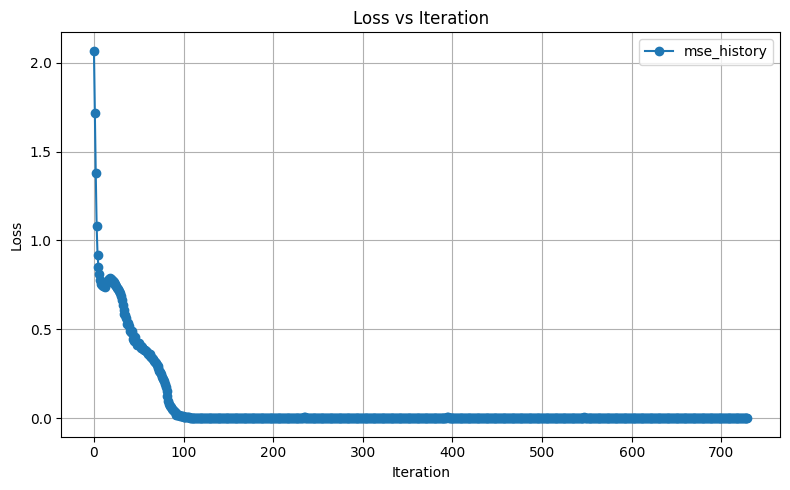

In [2]:

np.save(os.path.join(path, "mse_history.npy"), np.array(mse_history))
np.save(os.path.join(path, "test_mse_vs_epoch.npy"), np.array(test_mse_list))
np.save(os.path.join(path, "qfi_vs_epoch.npy"), np.array(qfi_list))
np.save(os.path.join(path, "epoch_list.npy"), np.array(epoch_list))

# ---------------- 绘图 ----------------
#训练过程： Epoch vs loss
plt.figure(figsize=(8, 5))
plt.plot(mse_history, marker='o', label="mse_history")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{path}/mse_history.png")
plt.show()


In [4]:
def compute_QFI(phi, x, dphi=1e-5):
    """中心差分计算纯态下的QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_q)

theta_flat_final, curly_flat_final, mlp_params_final = unpack_params(best_x)
q_params = pnp.concatenate([theta_flat_final, curly_flat_final])

QFI = compute_QFI(0.0, q_params)
print(f"QFI: {QFI:.4f}")
np.save(os.path.join(path, "QFI.npy"), np.array([QFI]))


QFI: 20.6553


<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:69: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_3280\2713890288.py:67: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_3280\2713890288.py:69: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")


Test MSE: 3.184780e-06


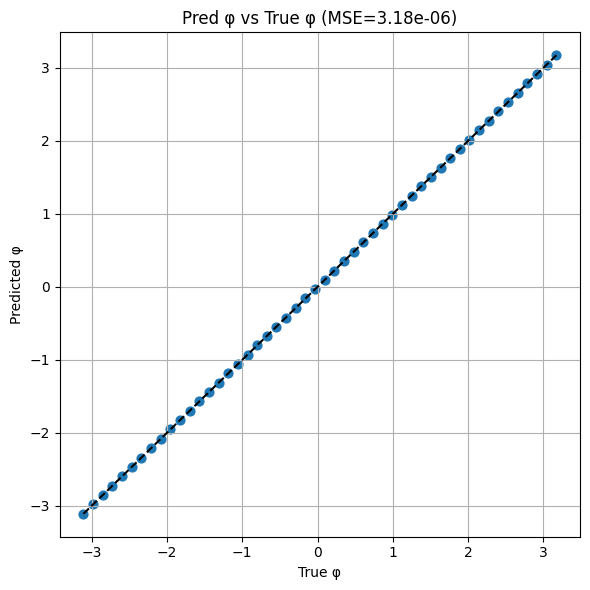

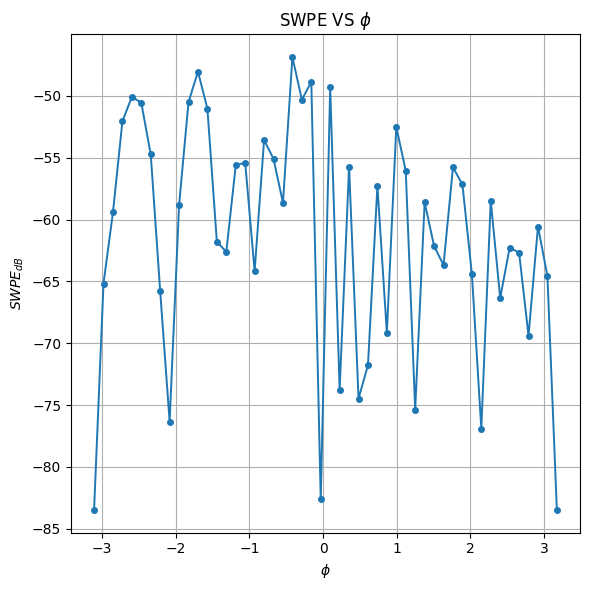

In [5]:
def adjust_phase_wrap(phi_true, phi_pred):
    """
    修正预测角度，使其在与真实角度相同的周期内（处理±π边界问题）。

    参数:
        phi_true: np.ndarray，真实相位（形状 [N]）
        phi_pred: np.ndarray，预测相位（形状 [N]）

    返回:
        phi_pred_adj: np.ndarray，修正后的预测相位
    """
    phi_pred_adj = phi_pred.copy()
    mask = np.abs(phi_true - phi_pred) > np.pi
    phi_pred_adj[mask] -= np.sign(phi_pred[mask]) * 2 * np.pi
    return phi_pred_adj

# after training, unpack final parameters and set net params
theta_flat_final, curly_flat_final, mlp_params_final = unpack_params(best_x)
net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = mlp_params_final

# -----------------------
# === Evaluate on test phis: phi_pred vs phi_true ===
# -----------------------
q_params_final = pnp.concatenate([theta_flat_final, curly_flat_final]) if (len(theta_flat_final) + len(curly_flat_final)) > 0 else pnp.array([])

phi_preds = []
for phi in phi_trues:
    probs = circuit_probs(phi, q_params_final)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(phi_pred))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_trues, phi_preds)

mse_test = np.mean((phi_preds - phi_trues) ** 2)
print(f"Test MSE: {mse_test:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds.npy"), phi_preds)
np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.scatter(phi_trues, phi_preds, s=40)
lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
plt.plot(lims, lims, '--', color='k')
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Pred φ vs True φ (MSE={mse_test:.2e})")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_{dB}$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE.png"), dpi=200)
plt.show()


<>:103: SyntaxWarning: invalid escape sequence '\p'
<>:105: SyntaxWarning: invalid escape sequence '\p'
<>:103: SyntaxWarning: invalid escape sequence '\p'
<>:105: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_3280\450340115.py:103: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_3280\450340115.py:105: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")
C:\Users\qingchuan.yang\AppData\Local\Programs\Python\Python313\Lib\site-packages\pennylane\devices\device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Test MSE: 6.837933e-06


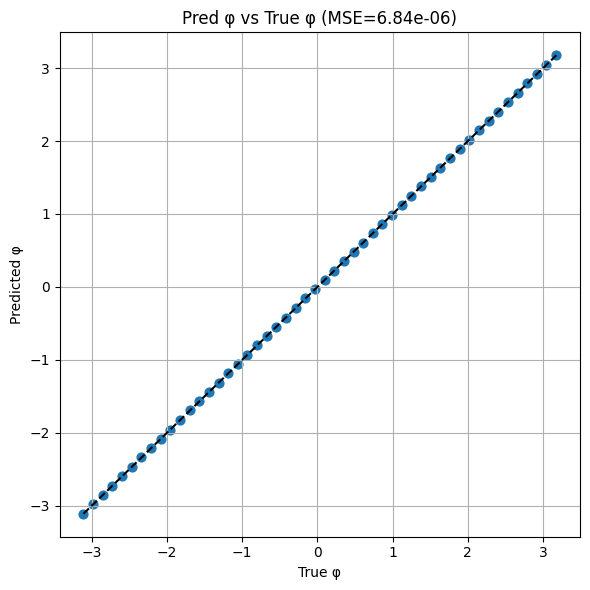

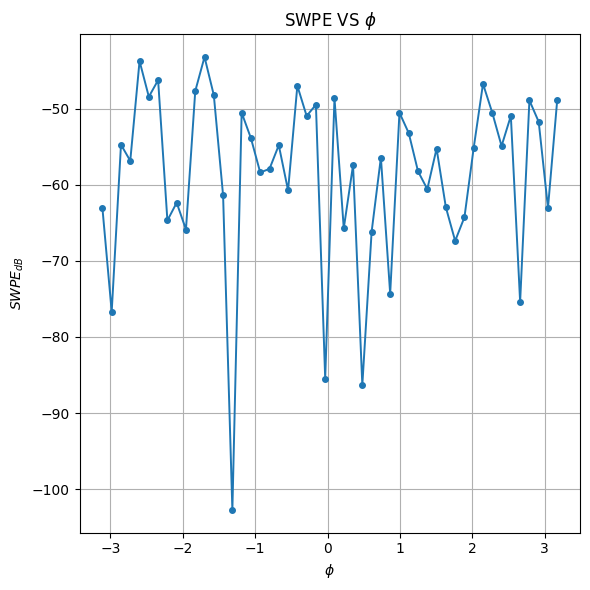

In [6]:
# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev_shots = qml.device("default.qubit", wires=n_qubits, shots=10**6)

@qml.qnode(dev_shots, interface="autograd")
def circuit_probs_shots(phi, q_params):
    """Return computational-basis probabilities for given phi and quantum parameters q_params."""
    # build same circuit but return probs
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=list(range(n_qubits)))


phi_preds = []
for phi in phi_trues:
    probs = circuit_probs_shots(phi, q_params_final)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(phi_pred))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_trues, phi_preds)

mse_test = np.mean((phi_preds - phi_trues) ** 2)
print(f"Test MSE: {mse_test:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds_shots.npy"), phi_preds)
np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.scatter(phi_trues, phi_preds, s=40)
lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
plt.plot(lims, lims, '--', color='k')
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Pred φ vs True φ (MSE={mse_test:.2e})")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true_shots.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_{dB}$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE_shots.png"), dpi=200)
plt.show()


In [13]:
import numpy as np

phi_list = phi_trues

def decoding_jacobian_stability(phi_true, phi_pred):
    """
    计算Jacobian的均值和方差
    """
    dphi = phi_true[1] - phi_true[0]
    J = np.gradient(phi_pred, dphi)
    
    J_mean = np.mean(J)
    J_var = np.var(J)
    
    return J_mean, J_var
    
phi_preds = []
for phi in phi_list:
    probs = circuit_probs(phi, q_params_final)
    p_m = probs_to_p_m(probs)
    v = net(p_m)                      # shape (2,)
    phi_pred = pnp.arctan2(v[0], v[1])
    phi_preds.append(float(qml.math.toarray(phi_pred)))

phi_preds = np.array(phi_preds)

# 修正角度跳变（±π跨越）
phi_preds = adjust_phase_wrap(phi_list, phi_preds)

J_mean, J_var = decoding_jacobian_stability(phi_list, phi_preds)

print("J_mean, J_var", J_mean, J_var)


J_mean, J_var 0.9999968942878045 0.00010310047034810306


In [9]:
import pickle

with open(os.path.join(path, "mlp_params.pkl"), "wb") as f:
    pickle.dump(mlp_params_final, f)

np.savez(
    os.path.join(path, "quantum_params.npz"),
    params=np.stack([theta_flat_final, curly_flat_final])
)

theta_flat_final, curly_flat_final

(tensor([0.64912776, 0.00435357, 0.39925465], requires_grad=True),
 tensor([0.21431721, 0.16754931, 0.77997415], requires_grad=True))

In [10]:
# import pickle
# import os

# with open(os.path.join(path, "mlp_params.pkl"), "rb") as f:
#     params = pickle.load(f)
# net.W1, net.b1, net.W2, net.b2, net.W3, net.b3 = params


# data = np.load(os.path.join(path, "quantum_params.npz"))

# theta_flat_final = data["params"][0]
# curly_flat_final = data["params"][1]


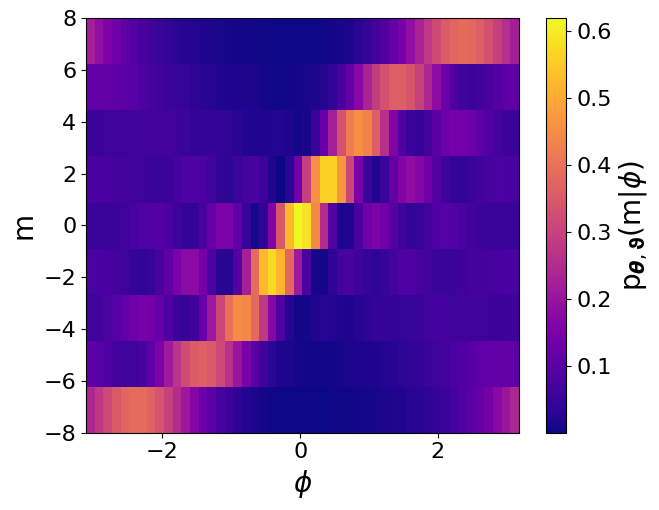

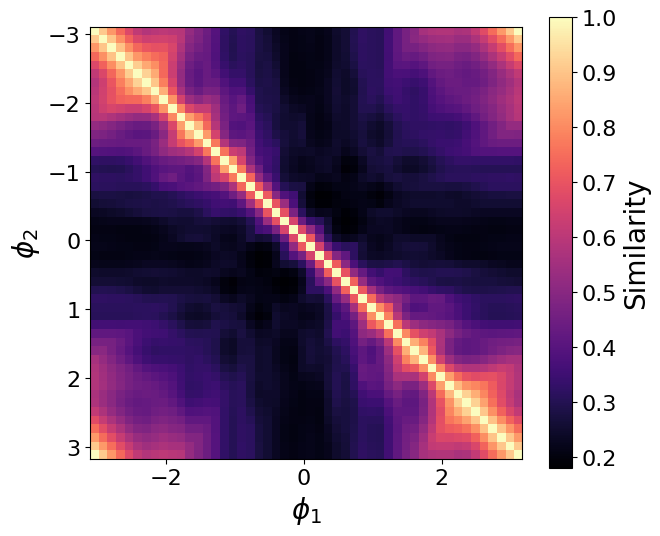

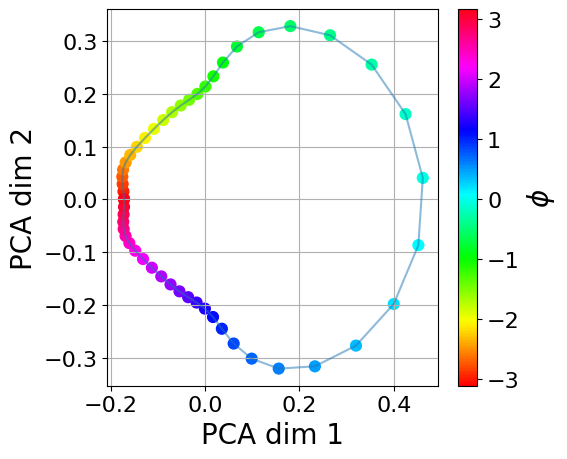

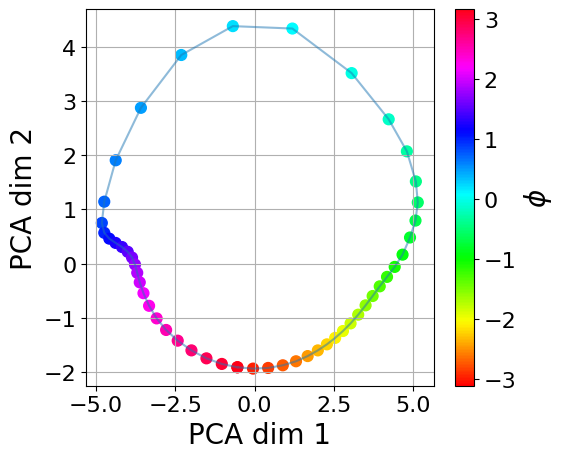

In [15]:
from sklearn.decomposition import PCA

act_func = "elu"
path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/{act_func}/figs"
os.makedirs(path, exist_ok=True)

q_params = pnp.concatenate([theta_flat_final, curly_flat_final])

plt.rcParams.update({
    "font.size": 20,          # 全局字体大小
    "axes.labelsize": 20,     # 坐标轴标签
    "xtick.labelsize": 16,    # x轴刻度
    "ytick.labelsize": 16,    # y轴刻度
    "legend.fontsize": 20,
})


def circuit_probs_batch(phi_array, q_params):
    
    probs_list = []

    for phi in phi_array:
        probs_list.append(circuit_probs(phi, q_params))

    return np.array(probs_list)

# ============================================================
# 1 Quantum Feature Map
# ============================================================
# Compute measurement probability distribution
# p(m | φ)
# ============================================================

def compute_feature_map(phi_trues, q_params):

    probs_batch = circuit_probs_batch(phi_trues, q_params)

    p_m_matrix = np.array([
        probs_to_p_m(p) for p in probs_batch
    ])

    return p_m_matrix

# ============================================================
# 2 Phase Sensitivity
# ============================================================
# Numerical derivative
#
# ∂p(m|φ) / ∂φ
# ============================================================

def compute_sensitivity(phi_trues, q_params):

    dphi = 1e-5

    probs_p = circuit_probs_batch(phi_trues + dphi, q_params)
    probs_m = circuit_probs_batch(phi_trues - dphi, q_params)

    p_plus = np.array([probs_to_p_m(p) for p in probs_p])
    p_minus = np.array([probs_to_p_m(p) for p in probs_m])

    dp_dphi = (p_plus - p_minus) / (2 * dphi)

    return dp_dphi


# ============================================================
# 3 Fisher Information Density
# ============================================================
# Classical Fisher information
#
# I(φ) = Σ ( (∂p/∂φ)^2 / p )
# ============================================================

def compute_fisher_density(p_m_matrix, dp_dphi):

    eps = 1e-12

    I_phi = np.sum(
        (dp_dphi ** 2) / (p_m_matrix + eps),
        axis=1
    )

    return I_phi

# ============================================================
# 4 Phase Identifiability Matrix
# ============================================================
# Measure similarity between phase distributions
#
# S(φ1,φ2) = exp( - ||p(φ1) - p(φ2)|| )
# ============================================================

def compute_phase_identifiability(p_m_matrix):

    n_phi = p_m_matrix.shape[0]

    S = np.zeros((n_phi, n_phi))

    for i in range(n_phi):
        for j in range(n_phi):

            dist = np.sum(np.abs(p_m_matrix[i] - p_m_matrix[j]))

            S[i, j] = np.exp(-dist)

    return S

# ============================================================
# 5 Neural Network Latent Feature
# ============================================================
# Extract hidden-layer representation
# ============================================================

def compute_nn_latent(phi_trues, q_params):

    latent_list = []

    for phi in phi_trues:

        probs = circuit_probs(phi, q_params)
        p_m = probs_to_p_m(probs)

        h1 = softsign(net.W1 @ p_m + net.b1)
        h2 = softsign(net.W2 @ h1 + net.b2)

        latent_list.append(h2)

    return np.array(latent_list)

# ============================================================
# Fig1 Quantum Feature Map
# ============================================================

def plot_feature_map(phi_trues, p_m_matrix, unique_m, path):

    plt.figure(figsize=(7,5.5))

    plt.imshow(
        p_m_matrix.T,
        aspect='auto',
        extent=[phi_trues[0], phi_trues[-1], unique_m[0], unique_m[-1]],
        origin='lower',
        cmap="plasma"
    )

    plt.colorbar(label=r"p$_{\boldsymbol{\theta}, \boldsymbol{\vartheta}}$(m|$\phi$)")
    plt.xlabel(r'$\phi$')
    plt.ylabel("m")
    # plt.title("Quantum feature heatmap")

    plt.tight_layout()

    plt.savefig(f"{path}/Quantum_feature_heatmap.png", dpi=300)


# ============================================================
# Fig2 Quantum Feature Embedding
# ============================================================

def plot_feature_embedding(p_m_matrix, phi_trues, path):

    pca = PCA(n_components=2)

    feature_2d = pca.fit_transform(p_m_matrix)

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        feature_2d[:,0],
        feature_2d[:,1],
        c=phi_trues,
        cmap="hsv",
        s=60
    )

    plt.plot(feature_2d[:,0], feature_2d[:,1], alpha=0.5)

    plt.colorbar(sc,label=r'$\phi$')

    plt.xlabel("PCA dim 1")
    plt.ylabel("PCA dim 2")
    # plt.title("Quantum feature embedding")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/feature_embedding.png", dpi=300)


# ============================================================
# Fig5  NN Latent Manifold
# ============================================================

def plot_latent_manifold(phi_trues, q_params, path):

    latent_arr = compute_nn_latent(phi_trues, q_params)

    pca = PCA(n_components=2)

    latent_2d = pca.fit_transform(latent_arr)

    plt.figure(figsize=(6,5))

    sc = plt.scatter(
        latent_2d[:,0],
        latent_2d[:,1],
        c=phi_trues,
        cmap="hsv",
        s=60
    )

    plt.plot(latent_2d[:,0], latent_2d[:,1], alpha=0.5)

    plt.colorbar(sc,label=r'$\phi$')

    plt.xlabel("PCA dim 1")
    plt.ylabel("PCA dim 2")

    # plt.title("Latent feature manifold")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/fig5_latent_manifold.png", dpi=300)

    plt.show()

# ============================================================
# Fig6  Phase Identifiability Map
# ============================================================

def plot_phase_identifiability_map(p_m_matrix, phi_trues, path):

    S = compute_phase_identifiability(p_m_matrix)

    plt.figure(figsize=(7,5.8))

    plt.imshow(
        S,
        extent=[phi_trues[0],phi_trues[-1],phi_trues[-1],phi_trues[0]],
        cmap="magma"
    )

    plt.colorbar(label="Similarity")

    plt.xlabel(r'$\phi_{1}$')
    plt.ylabel(r'$\phi_{2}$')

    # plt.title("Phase identifiability map")

    plt.tight_layout()

    plt.savefig(f"{path}/fig6_phase_identifiability.png", dpi=300)

    plt.show()



# ============================================================
# Main Analysis
# ============================================================

p_m_matrix = compute_feature_map(phi_trues, q_params)

dp_dphi = compute_sensitivity(phi_trues, q_params)

I_phi = compute_fisher_density(p_m_matrix, dp_dphi)

latent = compute_nn_latent(phi_trues, q_params)


plot_feature_map(phi_trues, p_m_matrix, unique_m, path)

plot_phase_identifiability_map(p_m_matrix, phi_trues, path)

plot_feature_embedding(p_m_matrix, phi_trues, path)

plot_latent_manifold(phi_trues, q_params, path)

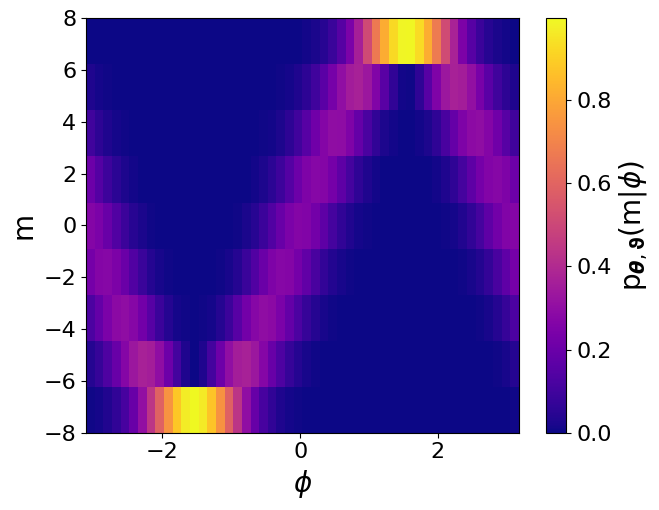

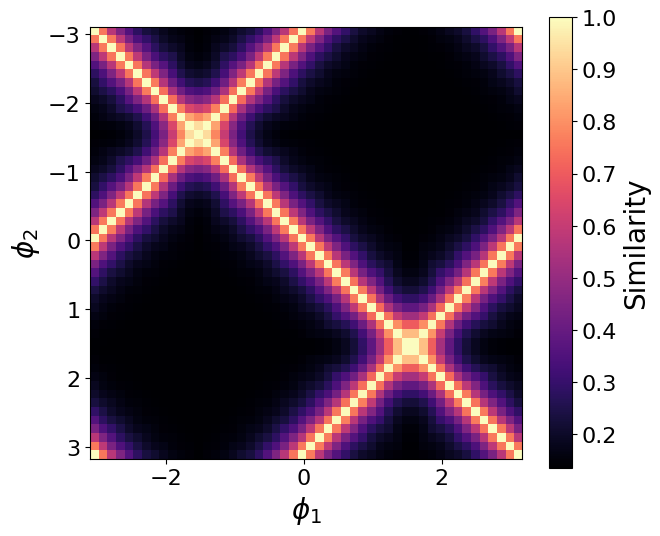

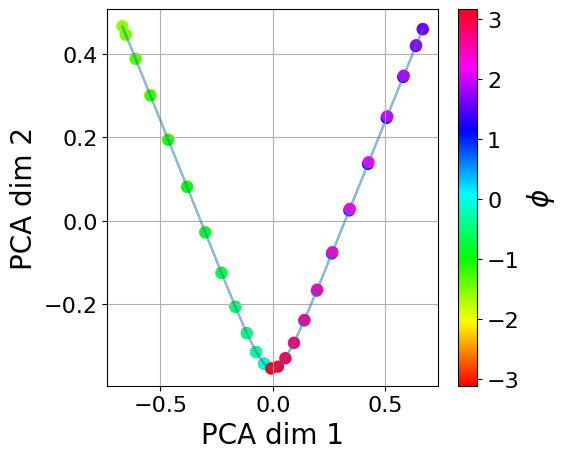

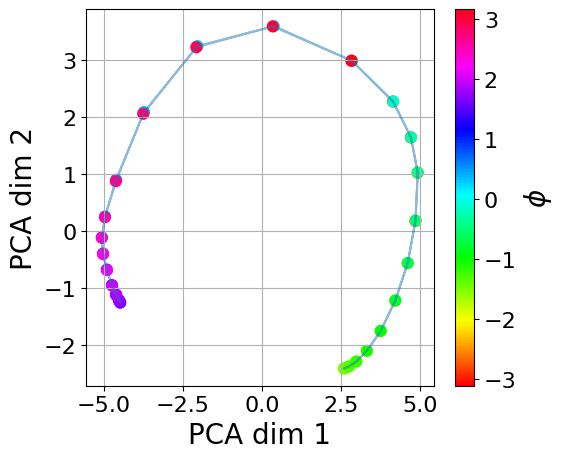

In [16]:

q_params_init = pnp.concatenate([theta_init, curly_init])

act_func = "elu"
path = f"VQ-CNNI/{n_qubits}/vqc_{n_enc}_{n_dec}/{act_func}/figs_init"
os.makedirs(path, exist_ok=True)


# ============================================================
# Main Analysis
# ============================================================

p_m_matrix = compute_feature_map(phi_trues, q_params_init)


plot_feature_map(phi_trues, p_m_matrix, unique_m, path)

plot_phase_identifiability_map(p_m_matrix, phi_trues, path)

plot_feature_embedding(p_m_matrix, phi_trues, path)

plot_latent_manifold(phi_trues, q_params_init, path)
